<a href="https://colab.research.google.com/github/Altz-L/Informatics/blob/main/DelhiClimate_11_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Графический анализ

Использовали dataset с kaggle: https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data/data исходный dataset был сразу разделён на тренеровачную и тестовую часть. Размер тренеровачной части: 1462 строки и 5 колонок; размер тестовой части: 114 строк и 5 колонок.

Подключаем библеотеки для работы с данными

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

С помощью переменной "train" мы обучаем модель. "test" мы проверяем модель

In [ ]:
train = pd.read_csv('DailyDelhiClimateTrain.csv')
test = pd.read_csv('DailyDelhiClimateTest.csv')

train.shape, test.shape

((1462, 5), (114, 5))

In [ ]:
test.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


Проверяем данные на наличие дубликатов, пустых значений и переводим время в удобный тип данных

In [ ]:
# удаляем дубликаты
train.drop_duplicates(subset=['date'], inplace=True)
test.drop_duplicates(subset=['date'], inplace=True)

train.shape, test.shape

((1462, 5), (114, 5))

In [ ]:
# удаляем пустые строки
train.dropna(subset=['date', 'meantemp'], inplace=True)
test.dropna(subset=['date', 'meantemp'], inplace=True)

train.shape, test.shape

((1462, 5), (114, 5))

In [ ]:
#меняем тип данных даты на datetime
train['date'] = pd.to_datetime(train['date'], format='mixed', errors='coerce')
test['date'] = pd.to_datetime(test['date'], format='mixed', errors='coerce')

In [ ]:
train.dtypes

,0
date,datetime64[ns]
meantemp,float64
humidity,float64
wind_speed,float64
meanpressure,float64


Находим средненедельную температуру и выводим график изменения средненедельной температуры в Делли за несеолько лет

In [ ]:
train_meantemp = train.resample('W', on='date')['meantemp'].mean()

train_meantemp.head(10)

,meantemp
date,
2013-01-06,7.705556
2013-01-13,12.343537
2013-01-20,13.642857
2013-01-27,12.329592
2013-02-03,15.736905
2013-02-10,15.856973
2013-02-17,16.012755
2013-02-24,17.708163
2013-03-03,18.661054


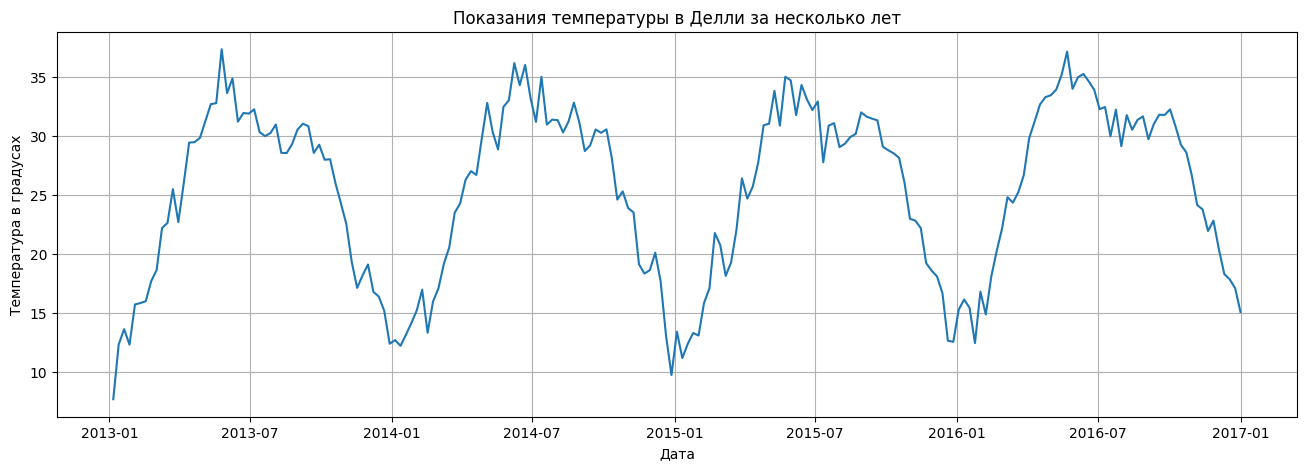

In [ ]:
plt.figure(figsize=(16, 5))
plt.title('Показания температуры в Делли за несколько лет')
plt.xlabel('Дата')
plt.ylabel('Температура в градусах')
plt.grid()

plt.plot(train_meantemp)
plt.show()

Смотря на график, можно увидеть, что в начале года холоднее, ближе к середине году теплеет, к концу года темература вновь опускается. Отсюда можно сделать вывод, что на графике прослеживается сезоннось.

##Обучение нейронки

Устанавливаем библеотеку prophet и подключаем её

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

Готовим данные для обучения модели

In [ ]:
train_0 = train.groupby(['date'])['meantemp'].mean().reset_index() # сгруппировали данные обучающей выборки
test_0 = test.groupby(['date'])['meantemp'].mean().reset_index() # сгруппировали данные контрольной выборки

In [ ]:
train_0.columns = ['ds', 'y']
test_0.columns = ['ds', 'y']

Создаём модель и обучаем её

In [ ]:
model = Prophet()
model

In [ ]:
model.fit(train_0) # подогнали модель под наши данные

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Делаем прогноз

In [ ]:
future = model.make_future_dataframe(periods=114)

,ds
1462,2017-01-02
1463,2017-01-03
1464,2017-01-04
1465,2017-01-05
1466,2017-01-06
...,...
1571,2017-04-21
1572,2017-04-22
1573,2017-04-23
1574,2017-04-24


In [ ]:
forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,24.690062,9.170709,14.297523,24.690062,24.690062,-12.939164,-12.939164,-12.939164,0.034028,0.034028,0.034028,-12.973191,-12.973191,-12.973191,0.0,0.0,0.0,11.750898
1,2013-01-02,24.690224,9.259527,14.365348,24.690224,24.690224,-12.803802,-12.803802,-12.803802,0.146257,0.146257,0.146257,-12.950059,-12.950059,-12.950059,0.0,0.0,0.0,11.886422
2,2013-01-03,24.690387,9.171819,14.238647,24.690387,24.690387,-12.844533,-12.844533,-12.844533,0.067150,0.067150,0.067150,-12.911683,-12.911683,-12.911683,0.0,0.0,0.0,11.845854
3,2013-01-04,24.690550,9.257469,14.584522,24.690550,24.690550,-12.832477,-12.832477,-12.832477,0.027528,0.027528,0.027528,-12.860005,-12.860005,-12.860005,0.0,0.0,0.0,11.858073
4,2013-01-05,24.690713,9.178354,14.168579,24.690713,24.690713,-12.866139,-12.866139,-12.866139,-0.069126,-0.069126,-0.069126,-12.797013,-12.797013,-12.797013,0.0,0.0,0.0,11.824573


In [ ]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1571,2017-04-21,33.016221,30.437041,35.499887
1572,2017-04-22,33.097820,30.561298,35.889048
1573,2017-04-23,33.144373,30.440891,35.735591
1574,2017-04-24,33.494840,30.953127,36.205709
1575,2017-04-25,33.699042,31.269284,36.253294


Строим график. Хвост на этом графике - это прогноз модели

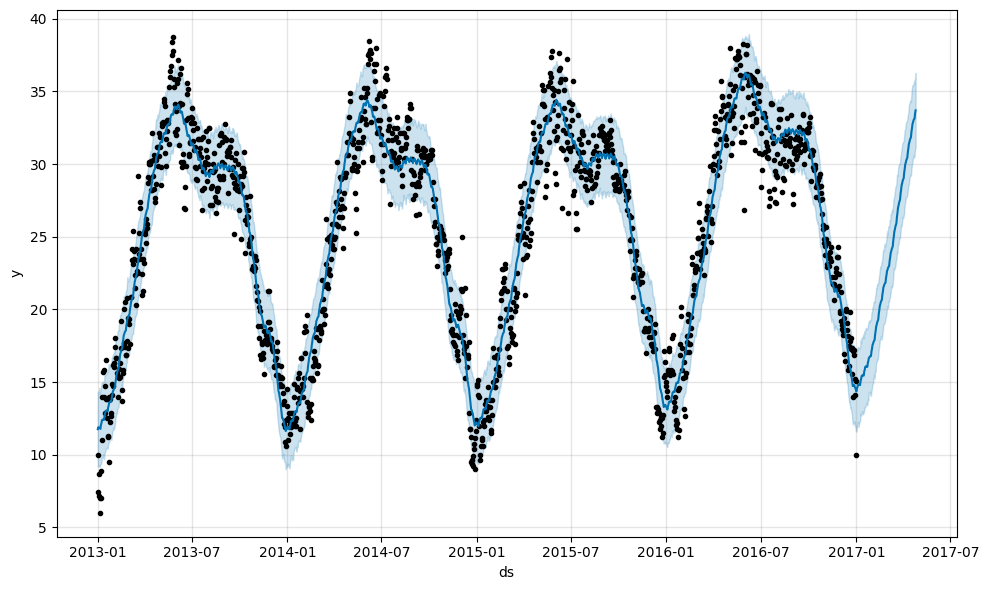

In [ ]:
model.plot(forecast);

Считаем погрешность прогноза

In [ ]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(forecast['yhat'].tail(114), test_0['y'])

2.2253201949036145

In [ ]:
np.mean(np.abs(forecast.tail(114).reset_index()['yhat'] - test_0['y'])/test_0['y'])*100

np.float64(11.867085262796094)

##Пробуем переобучить модель путем настройки параметров

In [ ]:
model_two = Prophet(growth='linear', yearly_seasonality=True, seasonality_mode='multiplicative')
model_two.fit(train_0)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_two = model_two.make_future_dataframe(periods=114)

In [ ]:
forecast_two = model_two.predict(future_two)

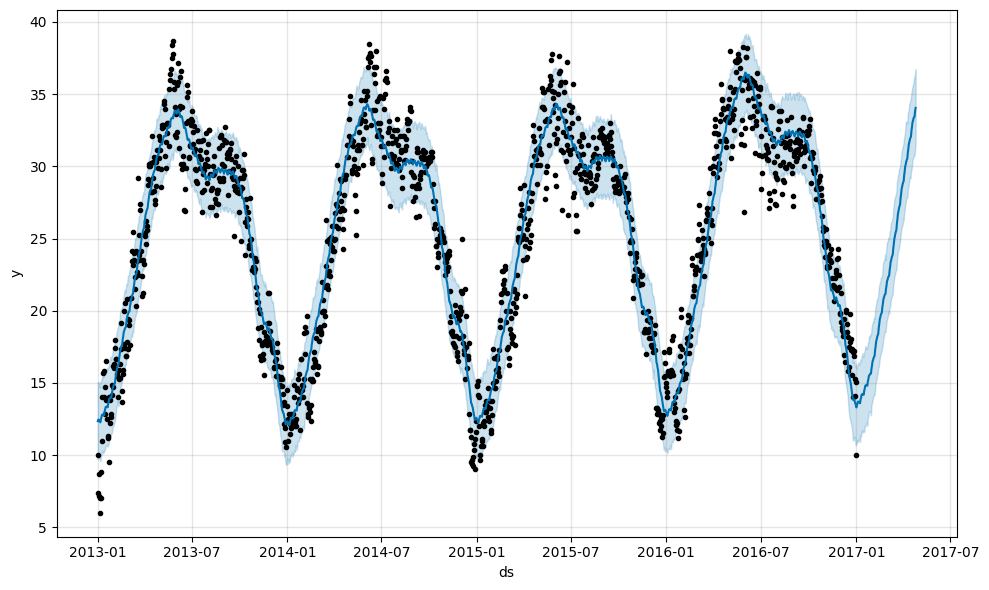

In [ ]:
model_two.plot(forecast_two);

In [ ]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(forecast_two['yhat'].tail(114), test_0['y'])

2.114527093098965

In [ ]:
np.mean(np.abs(forecast_two.tail(114).reset_index()['yhat'] - test_0['y'])/test_0['y'])*100

np.float64(10.887610494966502)

Удалось уменьшить процент ошибки на 1%
- старый процент ошибки: 11.867085262796094
- новый процент ошибки: 10.887610494966502

##Обучаем модель на всех данных

Объеденяем все данные

In [ ]:
all_data = pd.concat([train, test], ignore_index=True)
all_data = all_data.groupby(['date'])['meantemp'].mean().reset_index()
all_data.columns = ['ds', 'y']

Обучаем модель на всём наборе данных

In [ ]:
model_final = Prophet(growth='linear', yearly_seasonality=True, seasonality_mode='multiplicative')
model_final.fit(all_data)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Делаем прогноз на год вперёд

In [ ]:
future_final = model_final.make_future_dataframe(periods=365)

In [ ]:
forecast_final = model_final.predict(future_final)

Строим график прогноза, где хвост - это прогноз

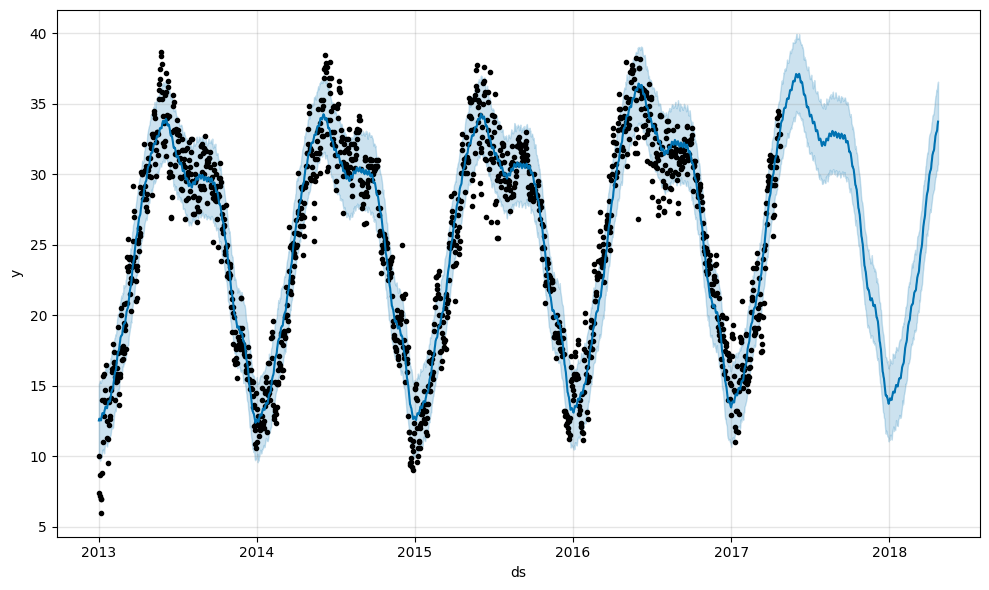

In [ ]:
model_final.plot(forecast_final);

Москивин Иван, Хома Глеб